# Exploration du dataset_flags_critiques.csv

    - Exploration du data
    - traitement 
    - Creation du dataset a envoyer dans le pipeline d'excution. 

In [ ]:
# import des bibliotheques utiliser dans la pluspart des cellules d'analyse
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.gridspec as gridspec



In [ ]:
# fichier brutes, analyse : 
# nom du fichier : dataset_flags_critiques.csv 
data_brute_path = ("dataset_flags_critique.csv") # fichier brute contenant les id qui ont des flags critiques. 
data_brute = pd.read_csv(data_brute_path)
data_brute.head(10)

,id,test,type_2
0,00bd6b3338,2,variante_principale
1,01122bb07c,2,variante_principale
2,01291e33de,2,variante_principale
3,0102327582,2,variante_principale
4,00ac059847,2,variante_principale
5,01147f917f,2,variante_principale
6,009bb21468,2,variante_principale
7,00f184cd57,2,variante_principale
8,02264dd398,2,variante_principale
9,00fd08e37d,2,variante_principale


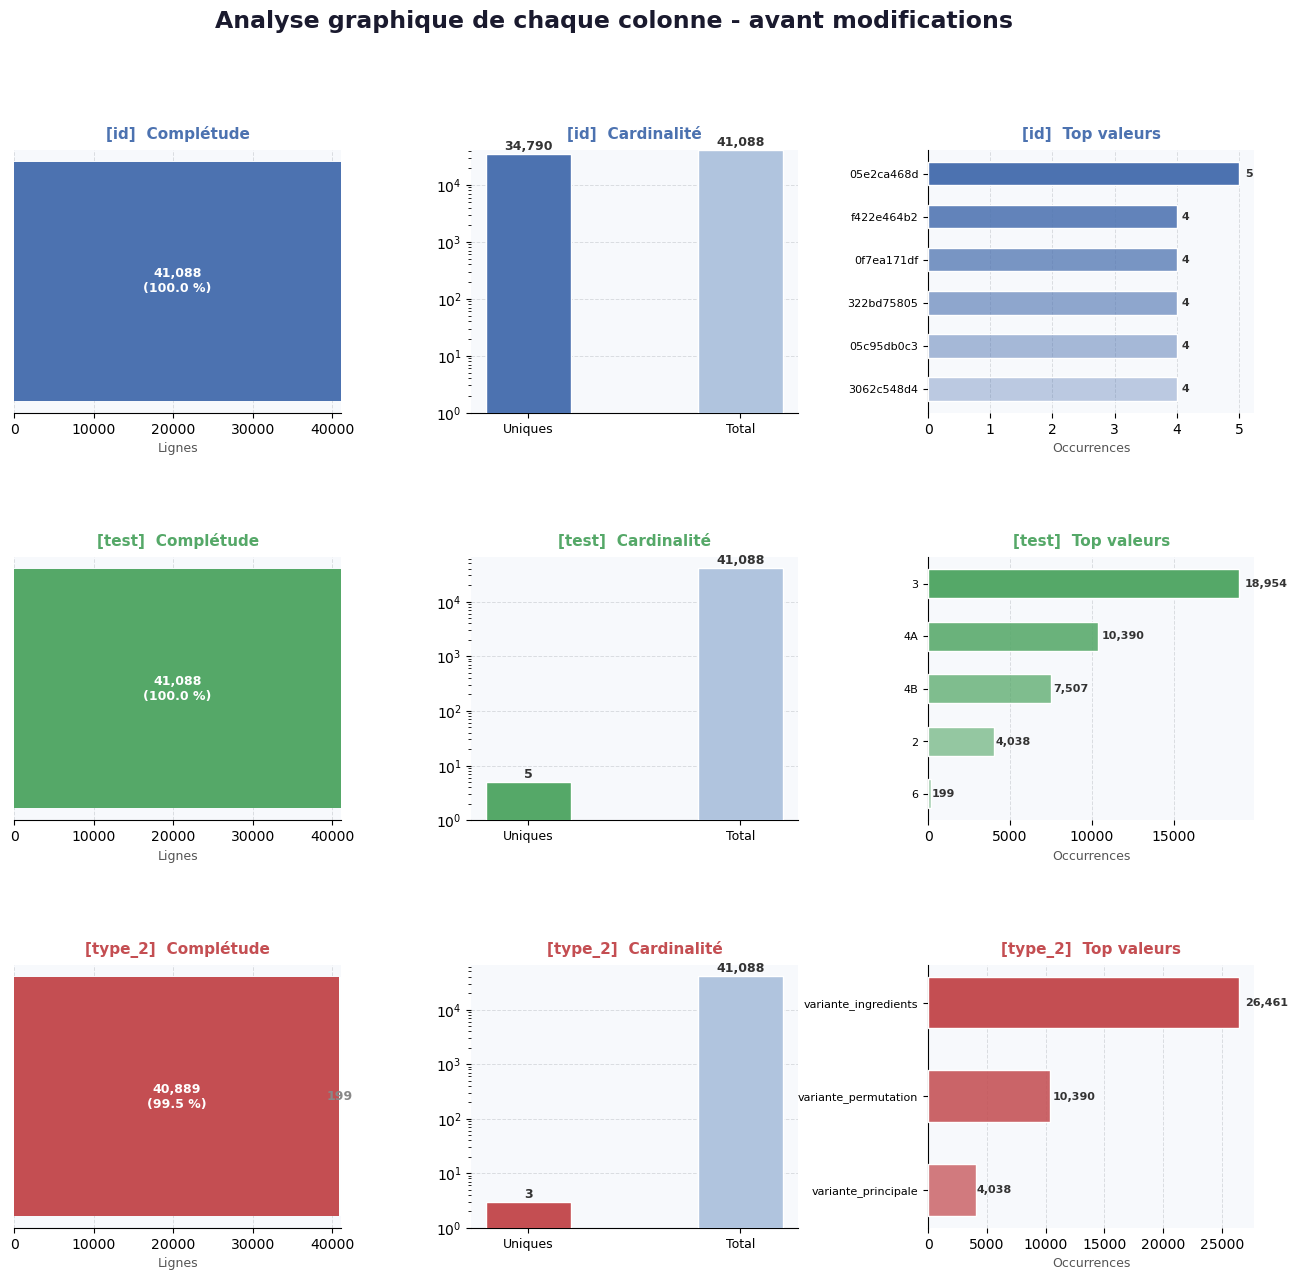

Figure sauvegardée : stats_par_colonne.png


In [ ]:
# ── Tableau de bord statistique — une colonne par panneau ─────────────────────

# Recharger les données originales
data_brute = pd.read_csv("dataset_flags_critique.csv")
total = len(data_brute)

COL_COLORS = {"id": "#4C72B0", "test": "#55A868", "type_2": "#C44E52"}
NA_COLOR   = "#FDFFFF"

fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor("#FFFFFF")
fig.suptitle("Analyse graphique de chaque colonne - avant modifications",
             fontsize=17, fontweight="bold", color="#1A1A2E", y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

for col_idx, col in enumerate(data_brute.columns):
    color = COL_COLORS.get(col, "#888888")
    series = data_brute[col]
    n_total   = len(series)
    n_nonnull = series.notna().sum()
    n_null    = series.isna().sum()
    n_unique  = series.nunique()
    vc        = series.value_counts()

    # ── Panneau 1 : complétude 
    ax1 = fig.add_subplot(gs[col_idx, 0])
    ax1.set_facecolor("#F7F9FC")
    ax1.barh([""], [n_nonnull], color=color,   height=0.4, label="Non-null", zorder=3)
    ax1.barh([""], [n_null],    color=NA_COLOR, height=0.4, left=n_nonnull, label="Null", zorder=3)
    ax1.set_xlim(0, n_total)
    ax1.set_title(f"[{col}]  Complétude", fontsize=11, fontweight="bold", color=color, pad=8)
    ax1.set_xlabel("Lignes", fontsize=9, color="#555")
    pct_ok = n_nonnull / n_total * 100
    ax1.text(n_nonnull / 2, 0, f"{n_nonnull:,}\n({pct_ok:.1f} %)",
             ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    if n_null > 0:
        ax1.text(n_nonnull + n_null / 2, 0, f"{n_null:,}",
                 ha="center", va="center", fontsize=9, fontweight="bold", color="#888")
    ax1.spines[["top","right","left"]].set_visible(False)
    ax1.tick_params(axis="y", left=False, labelleft=False)
    ax1.xaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.7, zorder=0)
    ax1.set_axisbelow(True)

    # ── Panneau 2 : cardinalité 
    ax2 = fig.add_subplot(gs[col_idx, 1])
    ax2.set_facecolor("#F7F9FC")
    bars = ax2.bar(["Uniques", "Total"], [n_unique, n_total],
                   color=[color, "#B0C4DE"], width=0.4, edgecolor="white", zorder=3)
    for bar, val in zip(bars, [n_unique, n_total]):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.04, f"{val:,}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333")
    ax2.set_yscale("log")
    ax2.set_ylim(bottom=1)
    ax2.set_title(f"[{col}]  Cardinalité", fontsize=11, fontweight="bold", color=color, pad=8)
    ax2.spines[["top","right","left"]].set_visible(False)
    ax2.yaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.7, zorder=0)
    ax2.set_axisbelow(True)
    ax2.tick_params(axis="x", labelsize=9)

    # ── Panneau 3 : distribution des top valeurs 
    ax3 = fig.add_subplot(gs[col_idx, 2])
    ax3.set_facecolor("#F7F9FC")
    top = vc.head(6)
    shades = [plt.matplotlib.colors.to_rgba(color, alpha=1 - i * 0.13) for i in range(len(top))]
    h_bars = ax3.barh(top.index.astype(str)[::-1], top.values[::-1],
                      color=shades[::-1], edgecolor="white", height=0.55, zorder=3)
    for bar, val in zip(h_bars, top.values[::-1]):
        ax3.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=8, fontweight="bold", color="#333")
    ax3.set_title(f"[{col}]  Top valeurs", fontsize=11, fontweight="bold", color=color, pad=8)
    ax3.set_xlabel("Occurrences", fontsize=9, color="#555")
    ax3.spines[["top","right","bottom"]].set_visible(False)
    ax3.xaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.7, zorder=0)
    ax3.set_axisbelow(True)
    ax3.tick_params(axis="y", labelsize=8)

plt.savefig("images/stats_par_colonne.png", dpi=150, bbox_inches="tight", facecolor="#FFFFFF")
plt.show()
print("Figure sauvegardée : stats_par_colonne.png")

In [ ]:
# drop de la colonne test: elle represente les test ou l'id a echouée. Pour la suite pas interessant de la trainer, une nouvelle analyse au complet va etre faite

data_brute.drop(columns=['test'], inplace=True)
data_brute.head(10) 

,id,type_2
0,00bd6b3338,variante_principale
1,01122bb07c,variante_principale
2,01291e33de,variante_principale
3,0102327582,variante_principale
4,00ac059847,variante_principale
5,01147f917f,variante_principale
6,009bb21468,variante_principale
7,00f184cd57,variante_principale
8,02264dd398,variante_principale
9,00fd08e37d,variante_principale


In [ ]:
#supprimer les N/A : Les ids N/A sont ceux qui ont deja ete soumis a des tests et ont echoues plusieurs fois, donc a retirer du dataset, elles sont pas bien fournies en informations pour etre traité.
data_brute_clean = data_brute[
    (data_brute["type_2"] != "NA") & 
    data_brute["type_2"].notna()
].copy()

print(f"nombre de lignes avant le nettoyage : {len(data_brute)} lignes")
print(f"nombre de lignes apres le nettoyage(suppresion des NA) : {len(data_brute_clean)} lignes")

nombre de lignes avant le nettoyage : 41088 lignes
nombre de lignes apres le nettoyage(suppresion des NA) : 40889 lignes


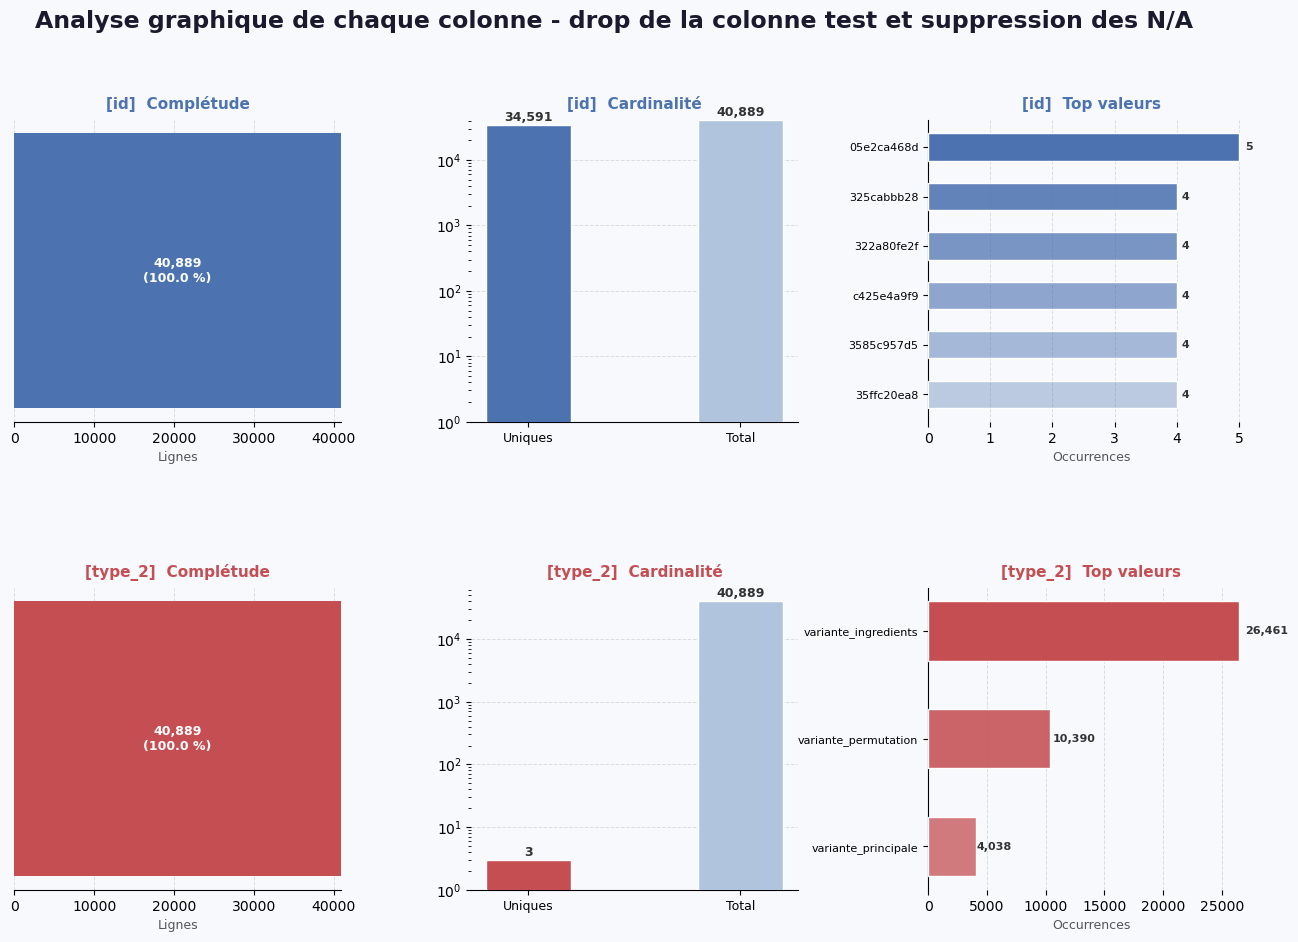

Figure sauvegardée : stats_brute_clean.png  (40,889 lignes)


In [ ]:
# ── Tableau de bord statistique — data_brute_clean 
COL_COLORS = {"id": "#4C72B0", "type_2": "#C44E52"}
NA_COLOR   = "#DADDE1"
total      = len(data_brute_clean)

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#F7F9FC")
fig.suptitle("Analyse graphique de chaque colonne - drop de la colonne test et suppression des N/A",
             fontsize=17, fontweight="bold", color="#1A1A2E", y=0.99)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.4)

for col_idx, col in enumerate(data_brute_clean.columns):
    color  = COL_COLORS.get(col, "#888888")
    series = data_brute_clean[col]
    n_nonnull = series.notna().sum()
    n_null    = series.isna().sum()
    n_unique  = series.nunique()
    vc        = series.value_counts()

    # ── Panneau 1 : complétude
    ax1 = fig.add_subplot(gs[col_idx, 0])
    ax1.set_facecolor("#F7F9FC")
    ax1.barh([""], [n_nonnull], color=color,   height=0.4, zorder=3)
    ax1.barh([""], [n_null],    color=NA_COLOR, height=0.4, left=n_nonnull, zorder=3)
    ax1.set_xlim(0, total)
    ax1.set_title(f"[{col}]  Complétude", fontsize=11, fontweight="bold", color=color, pad=8)
    ax1.set_xlabel("Lignes", fontsize=9, color="#555")
    pct_ok = n_nonnull / total * 100
    ax1.text(n_nonnull / 2, 0, f"{n_nonnull:,}\n({pct_ok:.1f} %)",
             ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    if n_null > 0:
        ax1.text(n_nonnull + n_null / 2, 0, f"{n_null:,}",
                 ha="center", va="center", fontsize=9, color="#888")
    ax1.spines[["top","right","left"]].set_visible(False)
    ax1.tick_params(axis="y", left=False, labelleft=False)
    ax1.xaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.7, zorder=0)
    ax1.set_axisbelow(True)

    # ── Panneau 2 : cardinalité 
    ax2 = fig.add_subplot(gs[col_idx, 1])
    ax2.set_facecolor("#F7F9FC")
    bars = ax2.bar(["Uniques", "Total"], [n_unique, total],
                   color=[color, "#B0C4DE"], width=0.4, edgecolor="white", zorder=3)
    for bar, val in zip(bars, [n_unique, total]):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.05, f"{val:,}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333")
    ax2.set_yscale("log")
    ax2.set_ylim(bottom=1)
    ax2.set_title(f"[{col}]  Cardinalité", fontsize=11, fontweight="bold", color=color, pad=8)
    ax2.spines[["top","right","left"]].set_visible(False)
    ax2.yaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.7, zorder=0)
    ax2.set_axisbelow(True)
    ax2.tick_params(axis="x", labelsize=9)

    # ── Panneau 3 : top valeurs 
    ax3 = fig.add_subplot(gs[col_idx, 2])
    ax3.set_facecolor("#F7F9FC")
    top    = vc.head(6)
    shades = [plt.matplotlib.colors.to_rgba(color, alpha=1 - i * 0.13) for i in range(len(top))]
    h_bars = ax3.barh(top.index.astype(str)[::-1], top.values[::-1],
                      color=shades[::-1], edgecolor="white", height=0.55, zorder=3)
    for bar, val in zip(h_bars, top.values[::-1]):
        ax3.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=8, fontweight="bold", color="#333")
    ax3.set_title(f"[{col}]  Top valeurs", fontsize=11, fontweight="bold", color=color, pad=8)
    ax3.set_xlabel("Occurrences", fontsize=9, color="#555")
    ax3.spines[["top","right","bottom"]].set_visible(False)
    ax3.xaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.7, zorder=0)
    ax3.set_axisbelow(True)
    ax3.tick_params(axis="y", labelsize=8)

plt.savefig("images/stats_brute_clean.png", dpi=150, bbox_inches="tight", facecolor="#F7F9FC")
plt.show()
print(f"Figure sauvegardée : stats_brute_clean.png  ({total:,} lignes)")

In [ ]:
# manipulation de la colonne "id": verification des modifications appliquees dans la cellule precedente
valeurs_manquantes = data_brute_clean["id"].isna().sum() 
id_doubles = data_brute_clean["id"].duplicated().sum() 

# manipulation de la colonne "type_2" :
valeurs_manquantes_type_2 = data_brute_clean["type_2"].isna().sum()
valeurs_na_type_2 = (data_brute_clean["type_2"] == "NA").sum()

# Affichage des résultats
print(f"Colonne 'id' :")
print(f"  Valeurs manquantes : {valeurs_manquantes}")
print(f"  Valeurs dupliquées : {id_doubles}")
print(f"Colonne 'type_2' :")
print(f"  Valeurs manquantes : {valeurs_manquantes_type_2}")
print(f"  Valeurs 'NA' : {valeurs_na_type_2}")  

Colonne 'id' :
  Valeurs manquantes : 0
  Valeurs dupliquées : 6298
Colonne 'type_2' :
  Valeurs manquantes : 0
  Valeurs 'NA' : 0


In [ ]:
# ── Analyse des IDs dupliqués : même ID avec plusieurs type_2 

# IDs qui apparaissent plus d'une fois
ids_dupliques = data_brute_clean[data_brute_clean["id"].duplicated(keep=False)]["id"].unique()
print(f"Nombre d'IDs qui apparaissent plus d'une fois : {len(ids_dupliques)}")

# Pour chaque ID dupliqué, combien de type_2 distincts ?
analyse = (
    data_brute_clean[data_brute_clean["id"].isin(ids_dupliques)]
    .groupby("id")["type_2"]
    .agg(nb_occurrences="count", nb_type2_distincts="nunique", types_2=lambda x: list(x.unique()))
    .reset_index()
)

# Séparer : IDs avec plusieurs type_2 différents vs même type_2 répété
multi_type  = analyse[analyse["nb_type2_distincts"] > 1]
meme_type   = analyse[analyse["nb_type2_distincts"] == 1]

print(f"\nIDs dupliqués avec type_2 DIFFÉRENTS  (ex: variante_ingredients + variante_permutation) : {len(multi_type)}")
print(f"IDs dupliqués avec le MÊME type_2 répété                                               : {len(meme_type)}")

print(f"\n── Exemples d'IDs avec plusieurs type_2 différents ──")
print(multi_type[["id","nb_occurrences","nb_type2_distincts","types_2"]].head(10).to_string(index=False))

print(f"\n── Exemples d'IDs avec le même type_2 répété ──")
print(meme_type[["id","nb_occurrences","nb_type2_distincts","types_2"]].head(10).to_string(index=False))

Nombre d'IDs qui apparaissent plus d'une fois : 5109

IDs dupliqués avec type_2 DIFFÉRENTS  (ex: variante_ingredients + variante_permutation) : 2416
IDs dupliqués avec le MÊME type_2 répété                                               : 2693

── Exemples d'IDs avec plusieurs type_2 différents ──
        id  nb_occurrences  nb_type2_distincts                                      types_2
000320b7ce               3                   2 [variante_ingredients, variante_permutation]
0019ae8eca               3                   2 [variante_permutation, variante_ingredients]
006adbbeee               4                   2 [variante_ingredients, variante_permutation]
0078549fb4               2                   2 [variante_permutation, variante_ingredients]
007ccaa5bc               2                   2 [variante_ingredients, variante_permutation]
00c20394bd               2                   2 [variante_permutation, variante_ingredients]
00d5a21ab9               2                   2 [variante_p

/var/folders/8y/132c5n416hv_xss1v6x1t6jc0000gn/T/ipykernel_49857/1562858026.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


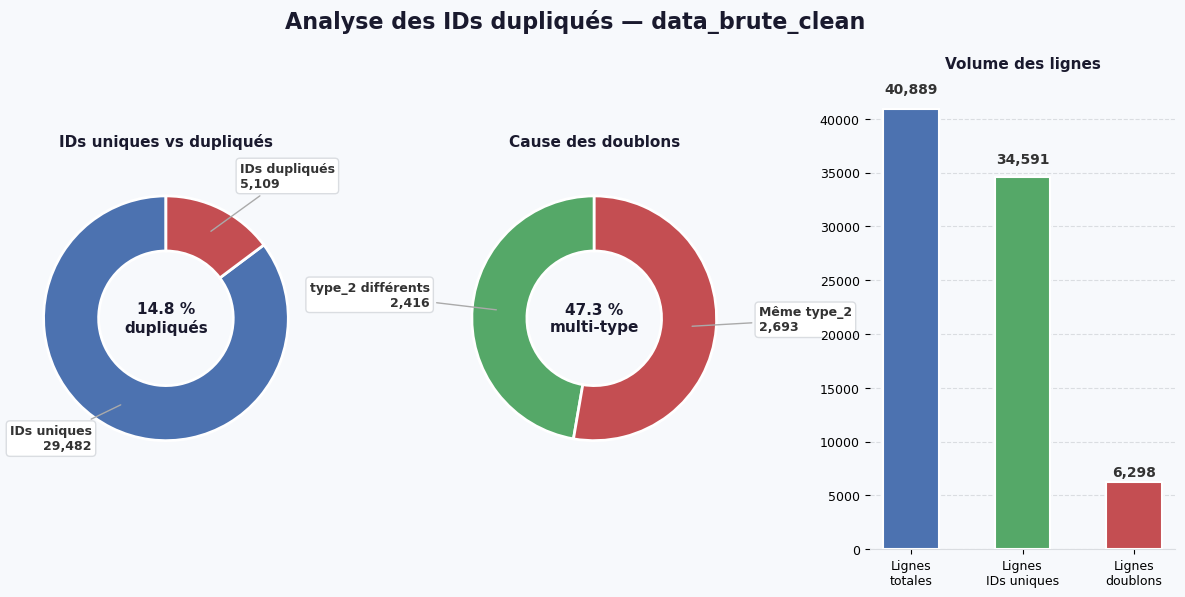

Figure sauvegardée : analyse_doublons.png


In [ ]:
# ── Graphique résumé — analyse des IDs dupliqués 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

total_ids      = data_brute_clean["id"].nunique()
ids_uniques    = total_ids - len(ids_dupliques)
ids_multi_type = len(multi_type)
ids_meme_type  = len(meme_type)
total_lignes   = len(data_brute_clean)
lignes_doubles = data_brute_clean["id"].duplicated().sum()

# Couleurs
C_UNIQUE = "#4C72B0"
C_MULTI  = "#55A868"
C_MEME   = "#C44E52"
C_BG     = "#F7F9FC"

fig = plt.figure(figsize=(15, 6))
fig.patch.set_facecolor(C_BG)
fig.suptitle("Analyse des IDs dupliqués — data_brute_clean",
             fontsize=16, fontweight="bold", color="#1A1A2E", y=1.01)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# ── Panneau 1 : Donut — IDs uniques vs dupliqués 
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(C_BG)
vals1   = [ids_uniques, len(ids_dupliques)]
colors1 = [C_UNIQUE, C_MEME]
labels1 = [f"IDs uniques\n{ids_uniques:,}", f"IDs dupliqués\n{len(ids_dupliques):,}"]
wedges, _ = ax1.pie(vals1, colors=colors1, startangle=90,
                    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2))
bbox = dict(boxstyle="round,pad=0.3", fc="white", ec="#DADDE1", lw=1)
for i, (w, lbl) in enumerate(zip(wedges, labels1)):
    ang = (w.theta2 + w.theta1) / 2
    x, y = np.cos(np.deg2rad(ang)), np.sin(np.deg2rad(ang))
    ax1.annotate(lbl, xy=(x*0.78, y*0.78),
                 xytext=(x*1.35, y*1.2),
                 ha="left" if x>0 else "right",
                 fontsize=9, fontweight="bold", color="#333",
                 arrowprops=dict(arrowstyle="-", color="#aaa", lw=1),
                 bbox=bbox)
pct_dup = len(ids_dupliques) / total_ids * 100
ax1.text(0, 0, f"{pct_dup:.1f} %\ndupliqués", ha="center", va="center",
         fontsize=11, fontweight="bold", color="#1A1A2E")
ax1.set_title("IDs uniques vs dupliqués", fontsize=11, fontweight="bold",
              color="#1A1A2E", pad=14)

# ── Panneau 2 : Donut — cause des doublons
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(C_BG)
vals2   = [ids_multi_type, ids_meme_type]
colors2 = [C_MULTI, C_MEME]
labels2 = [f"type_2 différents\n{ids_multi_type:,}", f"Même type_2\n{ids_meme_type:,}"]
wedges2, _ = ax2.pie(vals2, colors=colors2, startangle=90,
                     wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2))
for w, lbl in zip(wedges2, labels2):
    ang = (w.theta2 + w.theta1) / 2
    x, y = np.cos(np.deg2rad(ang)), np.sin(np.deg2rad(ang))
    ax2.annotate(lbl, xy=(x*0.78, y*0.78),
                 xytext=(x*1.35, y*1.2),
                 ha="left" if x>0 else "right",
                 fontsize=9, fontweight="bold", color="#333",
                 arrowprops=dict(arrowstyle="-", color="#aaa", lw=1),
                 bbox=bbox)
pct_multi = ids_multi_type / len(ids_dupliques) * 100
ax2.text(0, 0, f"{pct_multi:.1f} %\nmulti-type", ha="center", va="center",
         fontsize=11, fontweight="bold", color="#1A1A2E")
ax2.set_title("Cause des doublons", fontsize=11, fontweight="bold",
              color="#1A1A2E", pad=14)

# ── Panneau 3 : Barres — lignes totales vs lignes doublons 
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor(C_BG)
categories = ["Lignes\ntotales", "Lignes\nIDs uniques", "Lignes\ndoublons"]
vals3      = [total_lignes, total_lignes - lignes_doubles, lignes_doubles]
colors3    = [C_UNIQUE, C_MULTI, C_MEME]
bars = ax3.bar(categories, vals3, color=colors3, width=0.5,
               edgecolor="white", linewidth=1.5, zorder=3)
for bar, val in zip(bars, vals3):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.03,
             f"{val:,}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#333")
ax3.yaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.8, zorder=0)
ax3.set_axisbelow(True)
ax3.spines[["top","right","left"]].set_visible(False)
ax3.spines["bottom"].set_color("#DADDE1")
ax3.tick_params(axis="x", labelsize=9)
ax3.tick_params(axis="y", labelsize=9)
ax3.set_title("Volume des lignes", fontsize=11, fontweight="bold",
              color="#1A1A2E", pad=14)

plt.tight_layout()
plt.savefig("images/analyse_doublons.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("Figure sauvegardée : analyse_doublons.png")

In [ ]:
print(len(data_brute_clean.drop_duplicates(subset="id"))) # voir la nouvelle taille du dataset apres les modifications appliquées


34591


In [11]:
# ── Copie de référence : tous les type_2 par ID avant déduplication ───────────
# 1. Référence complète : tous les type_2 associés à chaque ID
type2_reference = (
    data_brute_clean.groupby("id")["type_2"]
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index()
    .rename(columns={"type_2": "type_2_tous"})
)

# Ajouter le nombre de type_2 distincts par ID
type2_reference["nb_type2"] = type2_reference["type_2_tous"].apply(len)

# Sauvegarde
type2_reference.to_csv("type2_par_id_reference.csv", index=False)

print(f"Référence sauvegardée : {len(type2_reference)} IDs uniques")
print(f"\nDistribution du nombre de type_2 par ID :")
print(type2_reference["nb_type2"].value_counts().sort_index().to_string())
print(f"\nAperçu :")
print(type2_reference.head(10).to_string(index=False))

Référence sauvegardée : 34591 IDs uniques

Distribution du nombre de type_2 par ID :
nb_type2
1    32175
2     2372
3       44

Aperçu :
        id                                  type_2_tous  nb_type2
000095fc1d                       [variante_permutation]         1
000320b7ce [variante_ingredients, variante_permutation]         2
001078d812                       [variante_ingredients]         1
0010cad8ab                        [variante_principale]         1
001404a16f                       [variante_ingredients]         1
00154ea0c2                       [variante_ingredients]         1
001577ef97                        [variante_principale]         1
0018861236                       [variante_ingredients]         1
0019ae8eca [variante_ingredients, variante_permutation]         2
001ab60ef2                       [variante_ingredients]         1


/var/folders/8y/132c5n416hv_xss1v6x1t6jc0000gn/T/ipykernel_49857/723989310.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


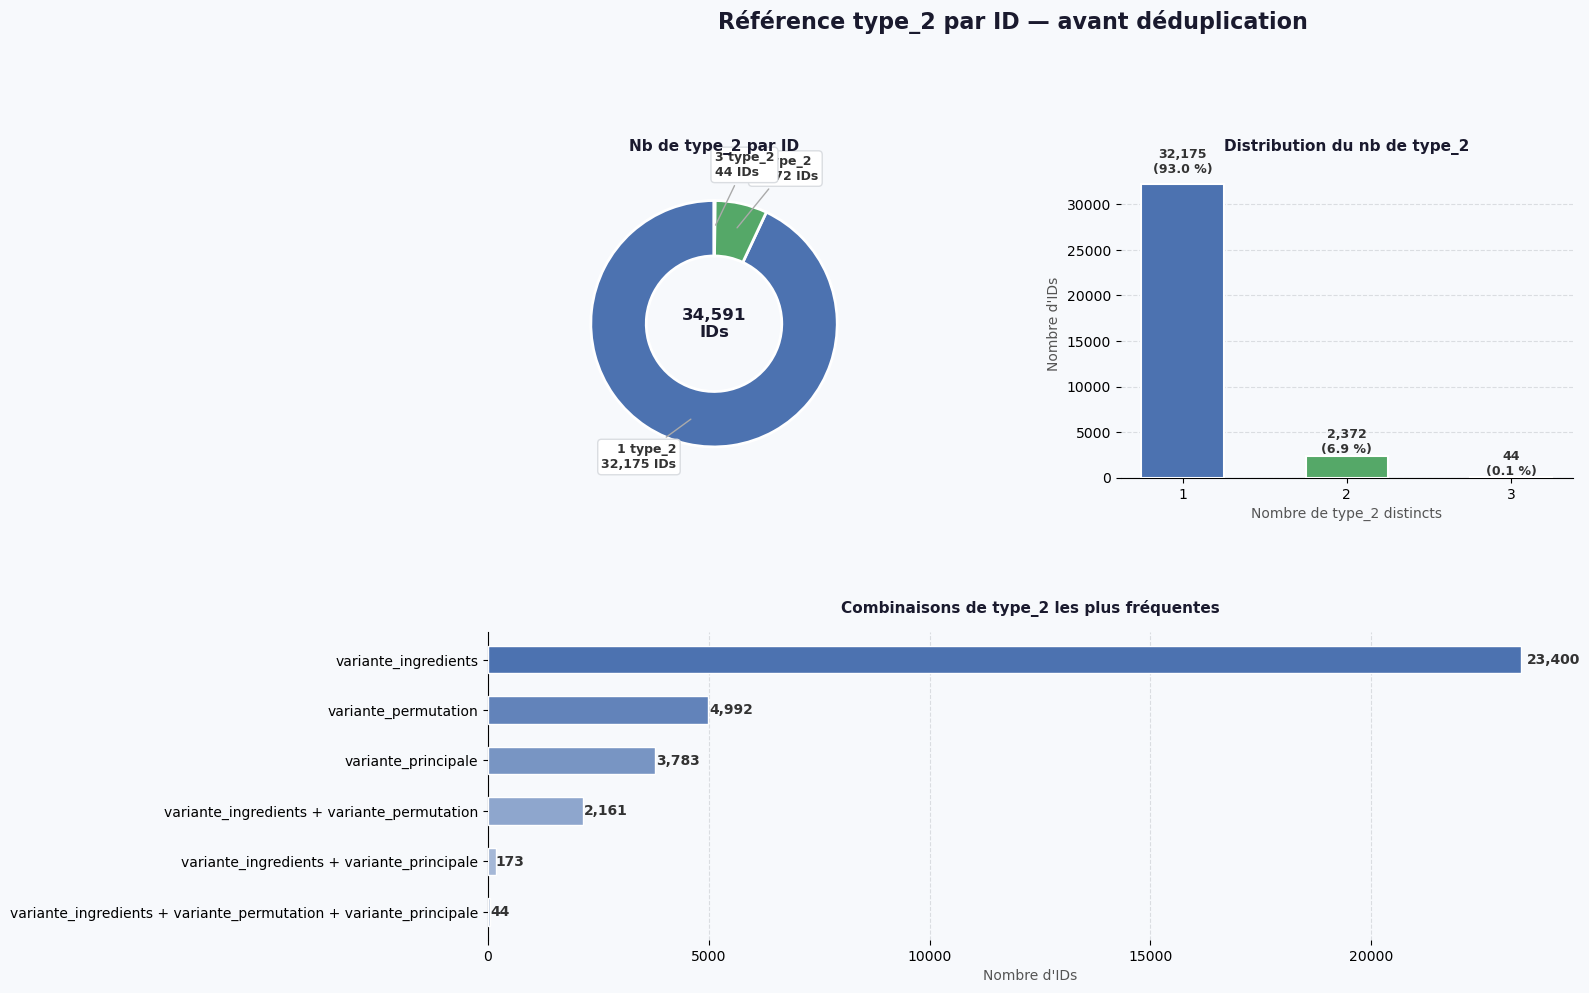

Figure sauvegardée : graphique_type2_reference.png


In [ ]:
# ── Graphique — type2_reference 
C_BG = "#F7F9FC"
palette = ["#4C72B0", "#55A868", "#C44E52", "#CCB974"]

dist = type2_reference["nb_type2"].value_counts().sort_index()

combo_counts = (
    type2_reference["type_2_tous"]
    .apply(lambda x: " + ".join(x))
    .value_counts()
    .head(6)
)

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor(C_BG)
fig.suptitle("Référence type_2 par ID — avant déduplication",
             fontsize=16, fontweight="bold", color="#1A1A2E", y=1.04)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.4)

# ── Panneau 1 (haut-gauche) : D
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(C_BG)
labels_d = [f"{n} type_2\n{v:,} IDs" for n, v in dist.items()]
wedges, _ = ax1.pie(dist.values, colors=palette[:len(dist)], startangle=90,
                    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2))
bbox = dict(boxstyle="round,pad=0.3", fc="white", ec="#DADDE1", lw=1)
for w, lbl in zip(wedges, labels_d):
    ang = (w.theta2 + w.theta1) / 2
    x, y = np.cos(np.deg2rad(ang)), np.sin(np.deg2rad(ang))
    ax1.annotate(lbl, xy=(x*0.78, y*0.78), xytext=(x*1.4, y*1.2),
                 ha="left" if x > 0 else "right",
                 fontsize=9, fontweight="bold", color="#333",
                 arrowprops=dict(arrowstyle="-", color="#aaa", lw=1), bbox=bbox)
ax1.text(0, 0, f"{len(type2_reference):,}\nIDs", ha="center", va="center",
         fontsize=12, fontweight="bold", color="#1A1A2E")
ax1.set_title("Nb de type_2 par ID", fontsize=11, fontweight="bold", color="#1A1A2E", pad=14)

# ── Panneau 2 (haut-droit) : Barres distribution 
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(C_BG)
bars = ax2.bar(dist.index.astype(str), dist.values,
               color=palette[:len(dist)], width=0.5, edgecolor="white", linewidth=1.5, zorder=3)
for bar, val in zip(bars, dist.values):
    pct = val / len(type2_reference) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.03,
             f"{val:,}\n({pct:.1f} %)", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#333")
ax2.set_xlabel("Nombre de type_2 distincts", fontsize=10, color="#555")
ax2.set_ylabel("Nombre d'IDs", fontsize=10, color="#555")
ax2.set_title("Distribution du nb de type_2", fontsize=11, fontweight="bold", color="#1A1A2E", pad=14)
ax2.spines[["top","right","left"]].set_visible(False)
ax2.yaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.8, zorder=0)
ax2.set_axisbelow(True)

# ── Panneau 3 (bas — pleine largeur) : Combinaisons
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor(C_BG)
shades = [plt.matplotlib.colors.to_rgba("#4C72B0", alpha=1 - i*0.13) for i in range(len(combo_counts))]
h_bars = ax3.barh(combo_counts.index[::-1], combo_counts.values[::-1],
                  color=shades[::-1], edgecolor="white", height=0.55, zorder=3)
for bar, val in zip(h_bars, combo_counts.values[::-1]):
    ax3.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=10, fontweight="bold", color="#333")
ax3.set_title("Combinaisons de type_2 les plus fréquentes", fontsize=11, fontweight="bold", color="#1A1A2E", pad=14)
ax3.set_xlabel("Nombre d'IDs", fontsize=10, color="#555")
ax3.spines[["top","right","bottom"]].set_visible(False)
ax3.xaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.8, zorder=0)
ax3.set_axisbelow(True)
ax3.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.savefig("images/graphique_type2_reference.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("Figure sauvegardée : graphique_type2_reference.png")

In [13]:
# -- jointure des id par aggregation pour avoir une ligne afin d'avoir une ligne: id, un type_2 representant le premier type_2 associe a l'id: 
len(data_brute_clean)
len(type2_reference)

34591

In [14]:
# drop de la colonne "type_2" 
# je vais l'enregistrer dans une nouvelle table pour l'utiliser comme outils de comparaison plus tard: 

data_2 = type2_reference.copy() 
data_id  = data_2.drop(columns=["type_2_tous","nb_type2"]) 
data_id.head(10)
data_2.head(10)

,id,type_2_tous,nb_type2
0,000095fc1d,[variante_permutation],1
1,000320b7ce,"[variante_ingredients, variante_permutation]",2
2,001078d812,[variante_ingredients],1
3,0010cad8ab,[variante_principale],1
4,001404a16f,[variante_ingredients],1
5,00154ea0c2,[variante_ingredients],1
6,001577ef97,[variante_principale],1
7,0018861236,[variante_ingredients],1
8,0019ae8eca,"[variante_ingredients, variante_permutation]",2
9,001ab60ef2,[variante_ingredients],1


/var/folders/8y/132c5n416hv_xss1v6x1t6jc0000gn/T/ipykernel_49857/423502196.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


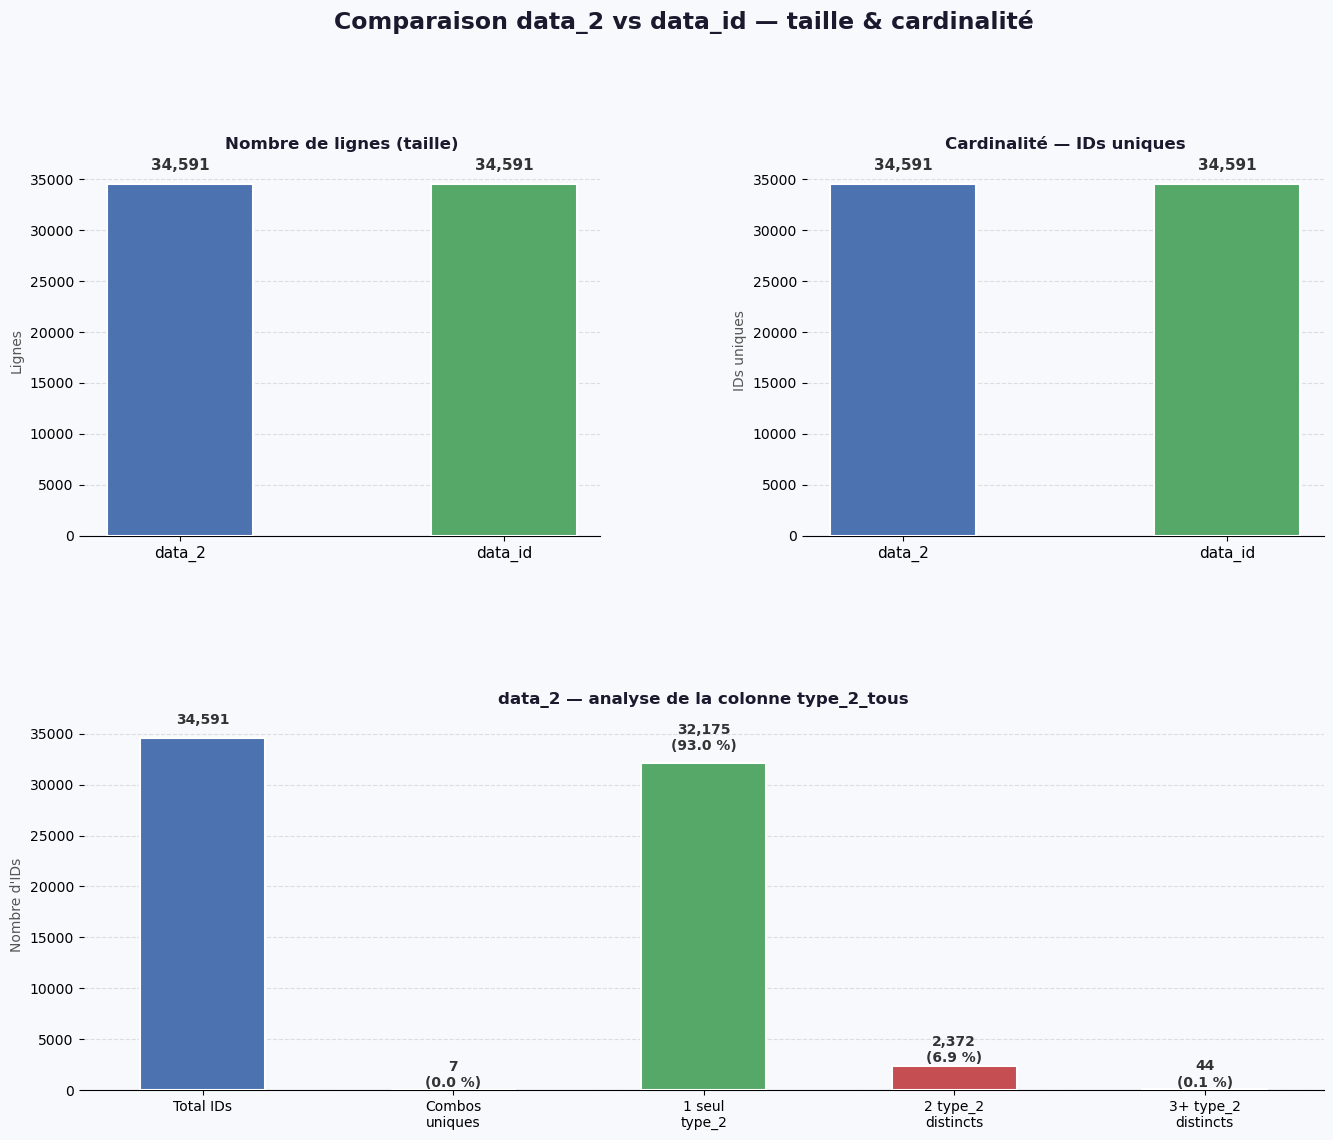

data_2  sauvegardé : 34,591 lignes  x  3 colonnes
data_id sauvegardé : 34,591 lignes  x  1 colonnes


In [ ]:
# ── Comparaison data_2 vs data_id 
C_BG     = "#F7F9FC"
C_DATA2  = "#4C72B0"
C_DATAID = "#55A868"
C_EXTRA  = "#CCB974"

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor(C_BG)
fig.suptitle("Comparaison data_2 vs data_id — taille & cardinalité",
             fontsize=17, fontweight="bold", color="#1A1A2E", y=1.01)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.4)

def style_ax(ax):
    ax.set_facecolor(C_BG)
    ax.spines[["top","right","left"]].set_visible(False)
    ax.yaxis.grid(True, color="#DADDE1", linestyle="--", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

def annotate_bars(ax, bars, values):
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.03, f"{val:,}",
                ha="center", va="bottom", fontsize=11, fontweight="bold", color="#333")

# ── Panneau 1 : Taille — nb lignes 
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
vals = [len(data_2), len(data_id)]
noms = ["data_2", "data_id"]
bars = ax1.bar(noms, vals, color=[C_DATA2, C_DATAID], width=0.45,
               edgecolor="white", linewidth=1.5, zorder=3)
annotate_bars(ax1, bars, vals)
ax1.set_title("Nombre de lignes (taille)", fontsize=12, fontweight="bold", color="#1A1A2E", pad=12)
ax1.set_ylabel("Lignes", fontsize=10, color="#555")
ax1.tick_params(axis="x", labelsize=11)

# ── Panneau 2  : Cardinalité — IDs uniques 
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)
vals2 = [data_2["id"].nunique(), data_id["id"].nunique()]
bars2 = ax2.bar(noms, vals2, color=[C_DATA2, C_DATAID], width=0.45,
                edgecolor="white", linewidth=1.5, zorder=3)
annotate_bars(ax2, bars2, vals2)
ax2.set_title("Cardinalité — IDs uniques", fontsize=12, fontweight="bold", color="#1A1A2E", pad=12)
ax2.set_ylabel("IDs uniques", fontsize=10, color="#555")
ax2.tick_params(axis="x", labelsize=11)

# ── Panneau 3 : data_2 — type_2_tous
ax3 = fig.add_subplot(gs[1, :])
style_ax(ax3)

n_combos_uniques = data_2["type_2_tous"].apply(tuple).nunique()
n_combos_total   = len(data_2)
n_1type          = (data_2["nb_type2"] == 1).sum()
n_2types         = (data_2["nb_type2"] == 2).sum()
n_3types         = (data_2["nb_type2"] >= 3).sum()

cat     = ["Total IDs", "Combos\nuniques", "1 seul\ntype_2", "2 type_2\ndistincts", "3+ type_2\ndistincts"]
vals3   = [n_combos_total, n_combos_uniques, n_1type, n_2types, n_3types]
colors3 = [C_DATA2, C_EXTRA, "#55A868", "#C44E52", "#9B59B6"]

bars3 = ax3.bar(cat, vals3, color=colors3, width=0.5,
                edgecolor="white", linewidth=1.5, zorder=3)
for bar, val in zip(bars3, vals3):
    pct = val / n_combos_total * 100
    label = f"{val:,}\n({pct:.1f} %)" if val != n_combos_total else f"{val:,}"
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.03, label,
             ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333")
ax3.set_title("data_2 — analyse de la colonne type_2_tous",
              fontsize=12, fontweight="bold", color="#1A1A2E", pad=12)
ax3.set_ylabel("Nombre d'IDs", fontsize=10, color="#555")
ax3.tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.savefig("images/comparaison_data2_dataid.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()

# ── Sauvegarde CSV 
data_2.to_csv("data_2.csv", index=False)
data_id.to_csv("data_id.csv", index=False)
print(f"data_2  sauvegardé : {len(data_2):,} lignes  x  {len(data_2.columns)} colonnes")
print(f"data_id sauvegardé : {len(data_id):,} lignes  x  {len(data_id.columns)} colonnes")

In [ ]:
#importation des donnees a jointre : 
# note: data_id est le data set ayant juste les ids et non le types de variantes. ceux si ont ete enregiste dans data_2 pour les utiliser comme outils de compoaraison plus tard.
data_instruction = pd.read_csv("recipe_instructions.csv") # prise des instructions de la recette 
data_ingredient = pd.read_csv("recipe_ingredients.csv") # prise des ingredients de la recette
data_recette = pd.read_csv("recipes.csv") # prise des recettes 

In [17]:
# jointure pour faire le dataset final: id + title + instruction + ingredients 
data_id.head(10) 

,id
0,000095fc1d
1,000320b7ce
2,001078d812
3,0010cad8ab
4,001404a16f
5,00154ea0c2
6,001577ef97
7,0018861236
8,0019ae8eca
9,001ab60ef2


In [18]:
#copie data.id pour faire les jointures :
data_final = data_id.copy() 
data_final.head(10)

,id
0,000095fc1d
1,000320b7ce
2,001078d812
3,0010cad8ab
4,001404a16f
5,00154ea0c2
6,001577ef97
7,0018861236
8,0019ae8eca
9,001ab60ef2


In [19]:
# jointure des instructions :
data_final = data_final.merge(data_recette[["id","title"]], on="id", how="left") 
data_final.head(10)

,id,title
0,000095fc1d,Yogurt Parfaits
1,000320b7ce,Tropical Banana Muffins
2,001078d812,Reuben in the Round
3,0010cad8ab,Garlic and Dill Salmon
4,001404a16f,Bacon Avocado Deviled Eggs
5,00154ea0c2,Chestnut-Apple Soup With Calvados Cream
6,001577ef97,How to Boil Water
7,0018861236,Corn Salad
8,0019ae8eca,Smoked Turkey Club Salad
9,001ab60ef2,Muffins Basic and Variations


In [20]:
# jointure des instructions: 
data_instruction["instruction"] = data_instruction["instruction"].fillna("") # retrait des instruction NAN
df_instruction_group = data_instruction.groupby("id")["instruction"].apply(" ".join).reset_index() # regroupe les instruction eparpille  
data_final = data_final.merge(df_instruction_group, on="id", how="left")
data_final.head(10)

,id,title,instruction
0,000095fc1d,Yogurt Parfaits,Layer all ingredients in a serving dish.
1,000320b7ce,Tropical Banana Muffins,Heat oven to 375F. Place paper baking cups int...
2,001078d812,Reuben in the Round,"In large bowl, stir together all ingredients e..."
3,0010cad8ab,Garlic and Dill Salmon,"In a food processor, process garlic to a rough..."
4,001404a16f,Bacon Avocado Deviled Eggs,Prepare eggs by placing in a single layer in a...
5,00154ea0c2,Chestnut-Apple Soup With Calvados Cream,Place prunes in a small bowl and add boiling w...
6,001577ef97,How to Boil Water,Open your cupboard or wherever it is you store...
7,0018861236,Corn Salad,Cut corn off the cob into a bowl. Chop one tom...
8,0019ae8eca,Smoked Turkey Club Salad,"Arrange turkey, tomato and bacon over greens o..."
9,001ab60ef2,Muffins Basic and Variations,Grease 12 2 1/2-inch muffin cups. Heat oven to...


In [21]:
# jointure avec les ingredients : 
data_ingredient["ingredient"] = data_ingredient["ingredient"].fillna("") # retrait des ingredient NAN
df_ingredient_group = data_ingredient.groupby("id")["ingredient"].apply(" ".join).reset_index() # regroupe les ingredient eparpille  
data_final = data_final.merge(df_ingredient_group, on="id", how="left")
data_final.head(10) 

,id,title,instruction,ingredient
0,000095fc1d,Yogurt Parfaits,Layer all ingredients in a serving dish.,"8 ounces, weight Light Fat Free Vanilla Yogurt..."
1,000320b7ce,Tropical Banana Muffins,Heat oven to 375F. Place paper baking cups int...,2 cups all-purpose flour 2 teaspoons baking po...
2,001078d812,Reuben in the Round,"In large bowl, stir together all ingredients e...",1 (16 ounce) container sour cream 12 cup thous...
3,0010cad8ab,Garlic and Dill Salmon,"In a food processor, process garlic to a rough...","2 (1.5 pound) salmon fillets 1 head garlic, pe..."
4,001404a16f,Bacon Avocado Deviled Eggs,Prepare eggs by placing in a single layer in a...,"12 whole Eggs 5 slices Bacon, Cooked And Crumb..."
5,00154ea0c2,Chestnut-Apple Soup With Calvados Cream,Place prunes in a small bowl and add boiling w...,"10 pitted prunes 1/4 cup Calvados or Cognac, m..."
6,001577ef97,How to Boil Water,Open your cupboard or wherever it is you store...,water salt (optional)
7,0018861236,Corn Salad,Cut corn off the cob into a bowl. Chop one tom...,leftover corn on the cob or canned corn ripe t...
8,0019ae8eca,Smoked Turkey Club Salad,"Arrange turkey, tomato and bacon over greens o...",1 pkg. (5.5 oz.) LOUIS RICH CARVING BOARD Smok...
9,001ab60ef2,Muffins Basic and Variations,Grease 12 2 1/2-inch muffin cups. Heat oven to...,2 cups unbleached all-purpose flour 1 tablespo...


In [ ]:
# shape du dataset final : dataset finale avec les 4 colonnes : id, title, instruction, ingredient
print(f"Dataset final : {len(data_final):,} lignes x {len(data_final.columns)} colonnes")   

Dataset final : 34,591 lignes x 4 colonnes


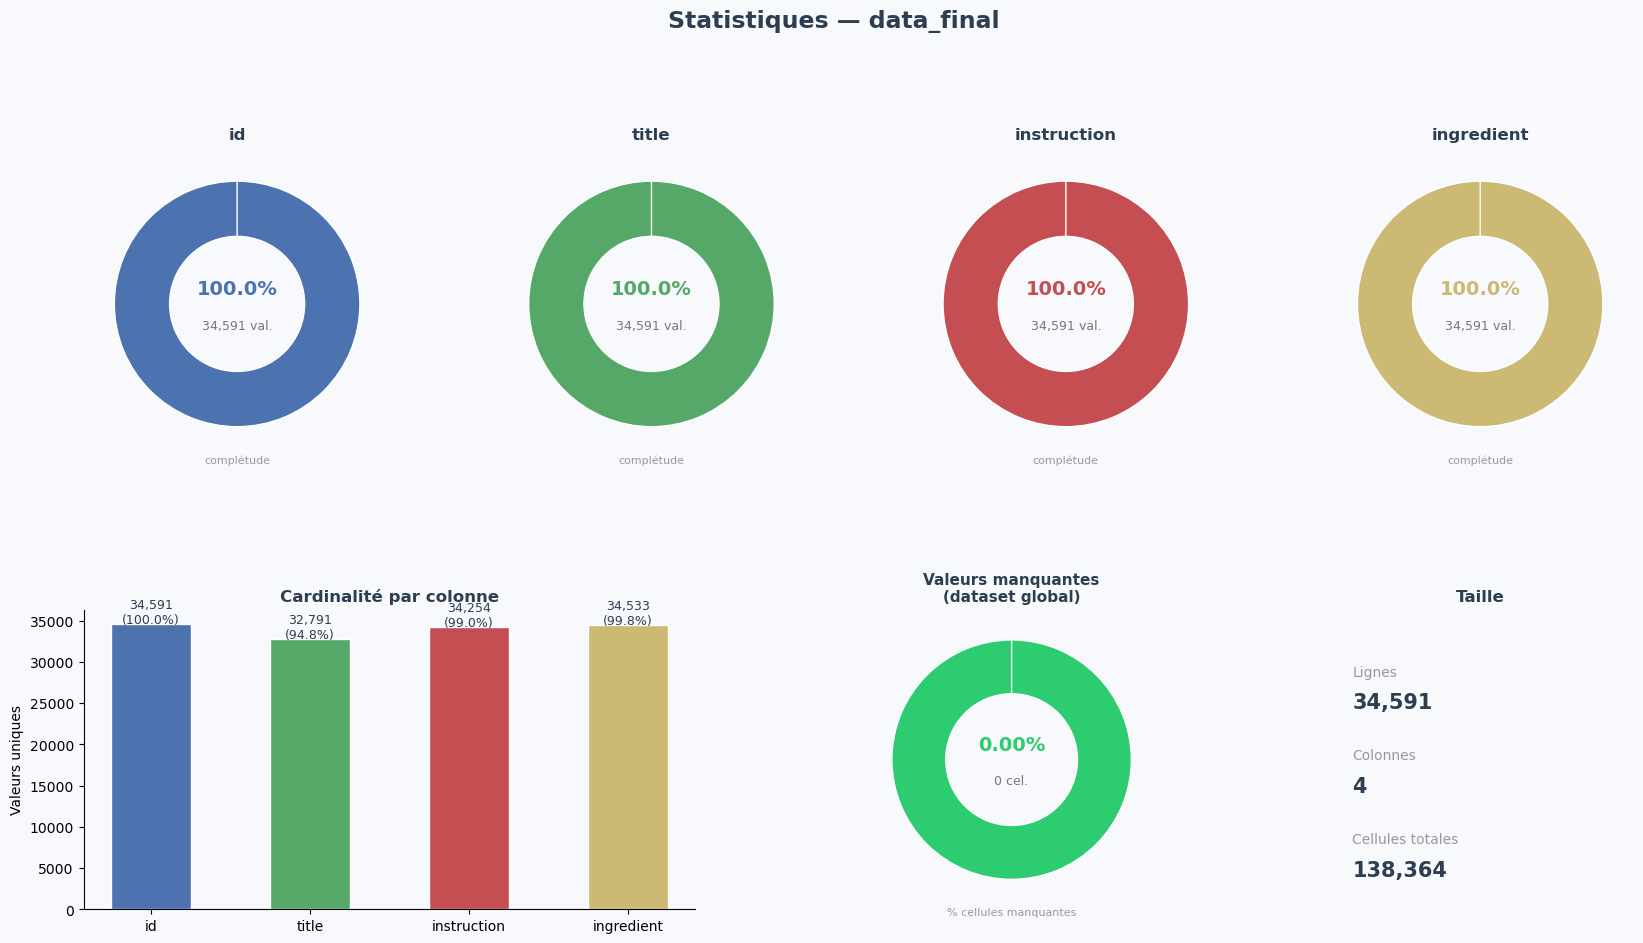

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

C_BG   = "#F7F9FC"
C_HDR  = "#2C3E50"
C_MISS = "#E74C3C"
C_OK   = "#2ECC71"
COLS   = list(data_final.columns)
palette = ["#4C72B0", "#55A868", "#C44E52", "#CCB974"]

n_rows, n_cols_df = data_final.shape
miss        = data_final.isna().sum()
pct_miss    = (miss / n_rows * 100).round(2)
completude  = (1 - miss / n_rows) * 100
card        = data_final.nunique()

# Manquantes globales (tout le dataset)
total_cells  = n_rows * n_cols_df
total_miss   = miss.sum()
pct_miss_global = total_miss / total_cells * 100
pct_ok_global   = 100 - pct_miss_global

# ── Figure 
fig = plt.figure(figsize=(20, 10))
fig.patch.set_facecolor(C_BG)
fig.suptitle("Statistiques — data_final", fontsize=17, fontweight="bold",
             color=C_HDR, y=1.01)

outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.45,
                          height_ratios=[1.1, 1])

# LIGNE 1 : 4 donuts (un par colonne)
top_gs = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[0], wspace=0.35)

for j, col in enumerate(COLS):
    ax = fig.add_subplot(top_gs[j])
    ax.set_facecolor(C_BG)
    clr     = palette[j]
    pct_ok  = completude[col]
    pct_ko  = pct_miss[col]
    n_valid = n_rows - miss[col]

    ax.pie(
        [pct_ok, pct_ko] if pct_ko > 0 else [100, 0],
        colors=[clr, "#EEEEEE"],
        startangle=90,
        wedgeprops=dict(width=0.45, edgecolor="white")
    )
    # Centre : % complétude
    ax.text(0, 0.12, f"{pct_ok:.1f}%", ha="center", va="center",
            fontsize=14, fontweight="bold", color=clr)
    ax.text(0, -0.18, f"{n_valid:,} val.", ha="center", va="center",
            fontsize=9, color="#777")

    ax.set_title(col, fontsize=12, fontweight="bold", color=C_HDR, pad=8)
    ax.text(0, -1.30, "complétude", ha="center", fontsize=8, color="#999")


# LIGNE 2 : cardinalité | manquantes globales | taille

bot_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[1],
                                          wspace=0.40, width_ratios=[2, 1, 1])

# ── Cardinalité 
ax_c = fig.add_subplot(bot_gs[0])
ax_c.set_facecolor(C_BG)
bars = ax_c.bar(COLS, card.values, color=palette[:len(COLS)],
                edgecolor="white", width=0.5)
for bar, v in zip(bars, card.values):
    pct = v / n_rows * 100
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + n_rows*0.003,
              f"{v:,}\n({pct:.1f}%)", ha="center", fontsize=9, color=C_HDR)
ax_c.set_title("Cardinalité par colonne", fontsize=12, fontweight="bold", color=C_HDR)
ax_c.set_ylabel("Valeurs uniques", fontsize=10)
ax_c.spines[["top","right"]].set_visible(False)
ax_c.set_facecolor(C_BG)

# ── Manquantes globales (donut)
ax_m = fig.add_subplot(bot_gs[1])
ax_m.set_facecolor(C_BG)
ax_m.pie(
    [pct_ok_global, pct_miss_global] if pct_miss_global > 0 else [100, 0],
    colors=[C_OK, C_MISS],
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor="white")
)
ax_m.text(0, 0.12, f"{pct_miss_global:.2f}%", ha="center", va="center",
          fontsize=14, fontweight="bold",
          color=C_MISS if pct_miss_global > 0 else C_OK)
ax_m.text(0, -0.18, f"{total_miss:,} cel.", ha="center", va="center",
          fontsize=9, color="#777")
ax_m.set_title("Valeurs manquantes\n(dataset global)", fontsize=11,
               fontweight="bold", color=C_HDR)
ax_m.text(0, -1.30, "% cellules manquantes", ha="center", fontsize=8, color="#999")

# ── Taille 
ax_t = fig.add_subplot(bot_gs[2])
ax_t.set_facecolor(C_BG)
ax_t.axis("off")
ax_t.set_title("Taille", fontsize=12, fontweight="bold", color=C_HDR)
infos = [
    ("Lignes",           f"{n_rows:,}"),
    ("Colonnes",         f"{n_cols_df}"),
    ("Cellules totales", f"{total_cells:,}"),
]
for i, (lbl, val) in enumerate(infos):
    y = 0.78 - i * 0.28
    ax_t.text(0.08, y,       lbl,  fontsize=10, color="#999",  transform=ax_t.transAxes)
    ax_t.text(0.08, y-0.11,  val,  fontsize=15, color=C_HDR,  fontweight="bold",
              transform=ax_t.transAxes)

plt.savefig("images/statistiques_data_final.png", dpi=150, bbox_inches="tight",
            facecolor=C_BG)
plt.show()

In [24]:
# ── Sauvegarde data_final → CSV (input pipeline LLM) ─────────────────────────
output_path = "data_final_pipeline.csv"
data_final.to_csv(output_path, index=False)

print(f"Sauvegardé : {output_path}")
print(f"  Lignes    : {len(data_final):,}")
print(f"  Colonnes  : {list(data_final.columns)}")
print(f"  Manquants : {data_final.isna().sum().to_dict()}")


Sauvegardé : data_final_pipeline.csv
  Lignes    : 34,591
  Colonnes  : ['id', 'title', 'instruction', 'ingredient']
  Manquants : {'id': 0, 'title': 0, 'instruction': 0, 'ingredient': 0}


pour voir ce dataset en csv, il faut ouvrir data_final_pipeline.csv